# Car Crash Severity Prediction


In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: Pre-processing ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# ── Scikit-learn: Models ─────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# ── Scikit-learn: Metrics ─────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)


---
## 1. Load Dataset

In [2]:
train_path = r"C:\Users\ganna\Downloads\car_crash_train.csv"
train_df = pd.read_csv(train_path)   # labeled training data

test_path = r"C:\Users\ganna\Downloads\car_crash_test.csv"
test_df  = pd.read_csv(test_path)   

print(f"Training set shape : {train_df.shape}")
print(f"Test set shape     : {test_df.shape}")
train_df.head()

Training set shape : (4000, 19)
Test set shape     : (1000, 19)


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic Info & Data Types

In [3]:
print("=== Dataset Info ===")
train_df.info()
missing_per_column = train_df.isnull().sum()
missing_per_column = missing_per_column[missing_per_column > 0]

missing_df = missing_per_column.reset_index()
missing_df.columns = ['Column', 'Missing Count']

print(missing_df)
print("\nTotal missing values in dataset:", missing_df['Missing Count'].sum())

missing_columns = train_df.columns[train_df.isnull().any()]

print("Columns with missing values:")
print(missing_columns.tolist())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       

=== Chi-Square Test: Distraction Level vs Categorical Features ===

Time of Day               → p=0.86177  ❌ Not significant
Crash Type                → p=0.47108  ❌ Not significant
Vehicle Type              → p=0.87689  ❌ Not significant
Airbag Deployed           → p=0.52533  ❌ Not significant
Seatbelt Used             → p=0.44387  ❌ Not significant

=== ANOVA Test: Distraction Level vs Numerical Features ===

Crash Speed (km/h)        → p=0.74756  ❌ Not significant
Driver Age                → p=0.89243  ❌ Not significant


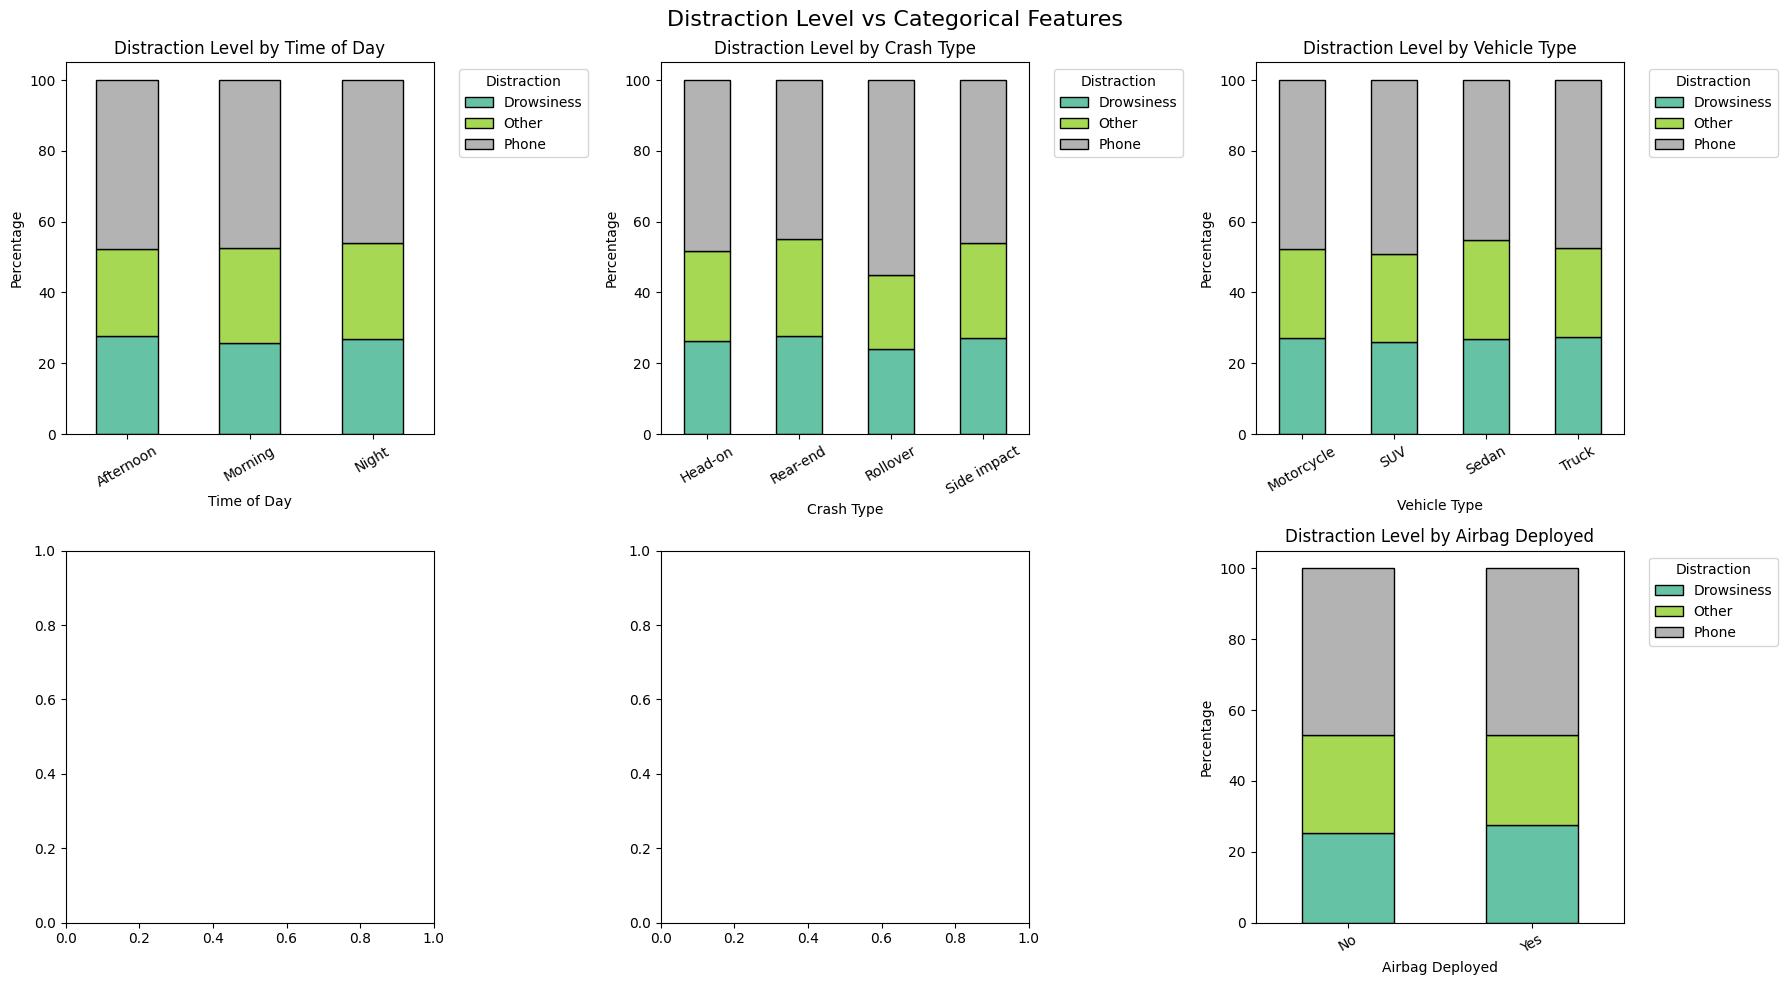

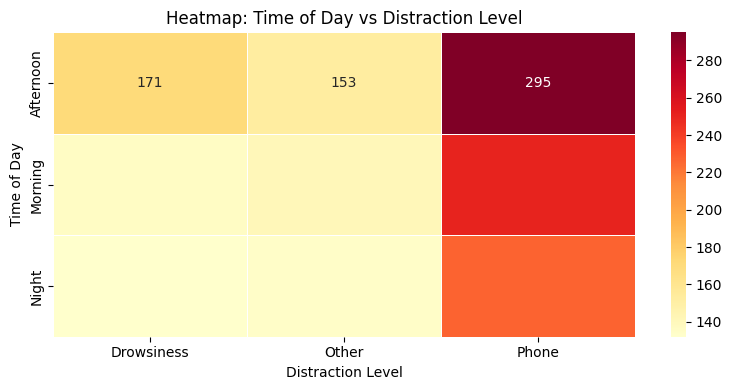

In [4]:
import scipy.stats as stats

# ── 1. Separate rows where Distraction Level is NOT missing ──────────────────
df_known = train_df[train_df['Distraction Level'].notna()].copy()

# ── 2. Chi-Square Test: Distraction vs Categorical Columns ───────────────────
# Chi-square tells us if two categorical variables are statistically related
cat_cols_to_test = ['Time of Day', 'Crash Type', 'Vehicle Type', 
                    'Weather Condition', 'Road Condition', 'Airbag Deployed',
                    'Seatbelt Used']

print("=== Chi-Square Test: Distraction Level vs Categorical Features ===\n")
chi2_results = []

for col in cat_cols_to_test:
    if col in df_known.columns:
        ct = pd.crosstab(df_known['Distraction Level'], df_known[col])
        chi2, p, dof, expected = stats.chi2_contingency(ct)
        chi2_results.append({'Feature': col, 'Chi2': round(chi2, 3), 'p-value': round(p, 5)})
        significance = "✅ Significant" if p < 0.05 else "❌ Not significant"
        print(f"{col:25s} → p={p:.5f}  {significance}")

# ── 3. ANOVA Test: Distraction vs Numerical Columns ──────────────────────────
# ANOVA checks if the mean of a numerical feature differs across distraction groups
num_cols_to_test = ['Crash Speed (km/h)', 'Driver Age', 'Driver Experience',
                    'Alcohol Level', 'Impact Angle', 'Vehicle Age']

print("\n=== ANOVA Test: Distraction Level vs Numerical Features ===\n")
anova_results = []

for col in num_cols_to_test:
    if col in df_known.columns:
        groups = [group[col].dropna().values 
                  for _, group in df_known.groupby('Distraction Level')]
        f_stat, p = stats.f_oneway(*groups)
        anova_results.append({'Feature': col, 'F-stat': round(f_stat, 3), 'p-value': round(p, 5)})
        significance = "✅ Significant" if p < 0.05 else "❌ Not significant"
        print(f"{col:25s} → p={p:.5f}  {significance}")

# ── 4. Visualize: Distraction Level vs Top Features ──────────────────────────

# Categorical: stacked bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_test[:6]):
    if col in df_known.columns:
        ct = pd.crosstab(df_known[col], df_known['Distraction Level'], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2', edgecolor='black')
        axes[i].set_title(f'Distraction Level by {col}')
        axes[i].set_ylabel('Percentage')
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].legend(title='Distraction', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Distraction Level vs Categorical Features', fontsize=16)
plt.tight_layout()
plt.show()



# ── 5. Heatmap: Distraction Level vs Time of Day ─────────────────────────────
if 'Time of Day' in df_known.columns:
    ct = pd.crosstab(df_known['Time of Day'], df_known['Distraction Level'])
    plt.figure(figsize=(8, 4))
    sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
    plt.title('Heatmap: Time of Day vs Distraction Level')
    plt.tight_layout()
    plt.show()

### Target Variable Distribution

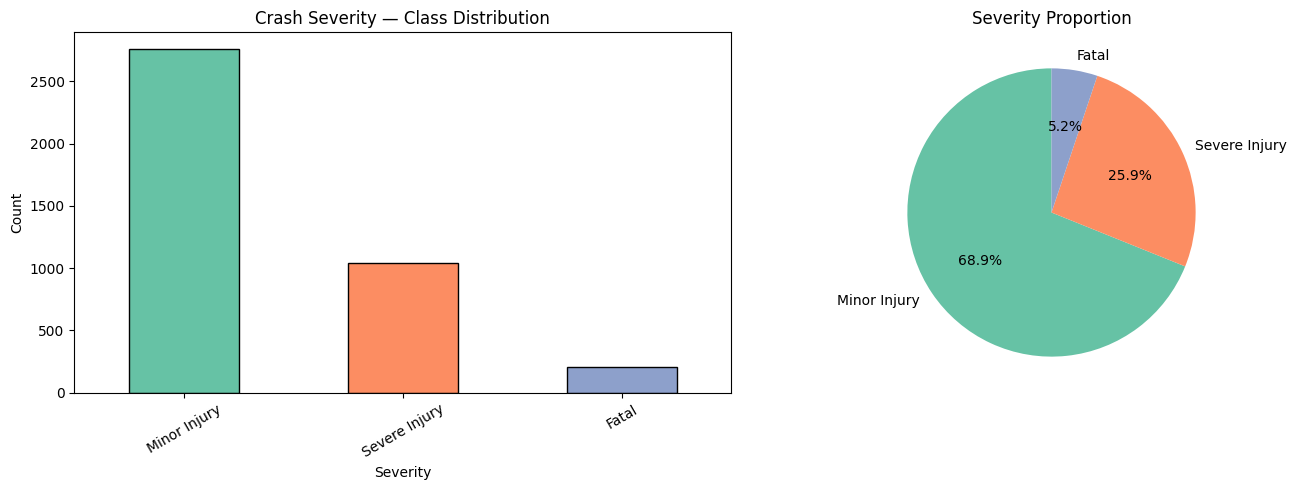


Class counts:
Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64


In [6]:
target_col = 'Severity'
severity_counts = train_df[target_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
severity_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Crash Severity — Class Distribution')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Severity Proportion')

plt.tight_layout()
plt.show()

print("\nClass counts:")
print(severity_counts)

# Comment:
# Observing whether the dataset is balanced or imbalanced is critical.
# If one class (e.g., 'Fatal') is heavily under-represented, we may need
# to apply class_weight='balanced' in our models or use oversampling.

###  Missing Values

Total missing values in the training set: 2360

Missing values per column:
                   Missing Count  Missing %
Distraction Level           2360       59.0


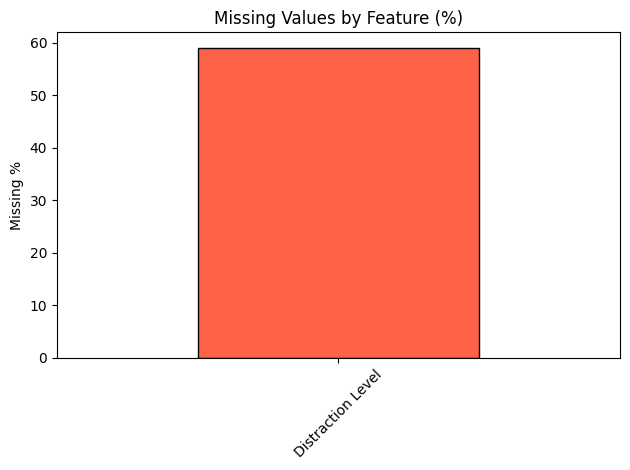

In [7]:
missing = train_df.isnull().sum()
total_missing = missing.sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"Total missing values in the training set: {total_missing}")

if missing_df.empty:
    print("✅ No missing values found in the training set.")
else:
    print("\nMissing values per column:")
    print(missing_df)
    
    # Visualize
    missing_df['Missing %'].plot(kind='bar', color='tomato', edgecolor='black')
    plt.title('Missing Values by Feature (%)')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Numerical Feature Distributions

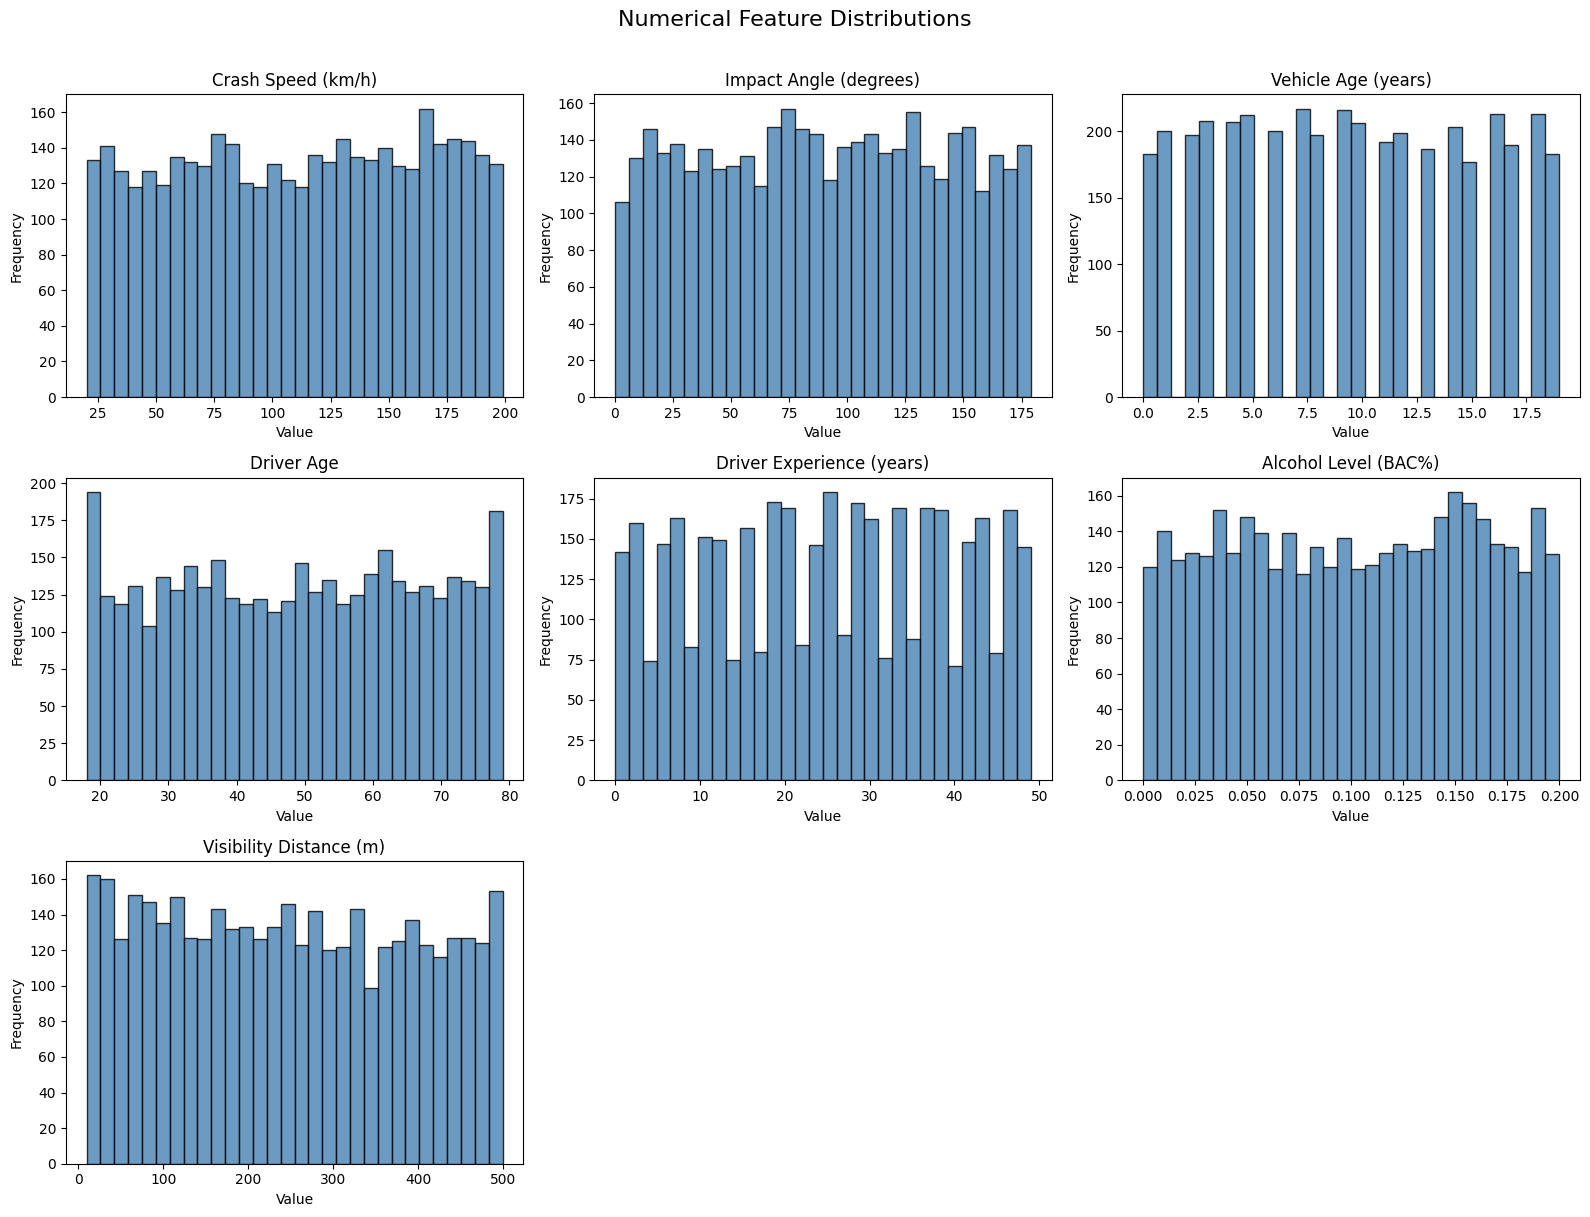

In [8]:
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(train_df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# Comment:
# We check for skewness, outliers, and value ranges.
# Highly skewed features may benefit from log-transformation.
# Features on vastly different scales need standardization for distance-based models (KNN, LR).

Distribution Analysis:

All numerical features (Crash Speed, Impact Angle, Vehicle Age, Driver Age, Driver Experience, Alcohol Level, and Visibility Distance) follow a near-uniform distribution, meaning values are spread roughly equally across their entire range with no significant skewness or outliers.



### Check for class imbalance

In [9]:
#check for class imbalance in target variable
print(train_df['Severity'].value_counts())


Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64


### Check for outliers

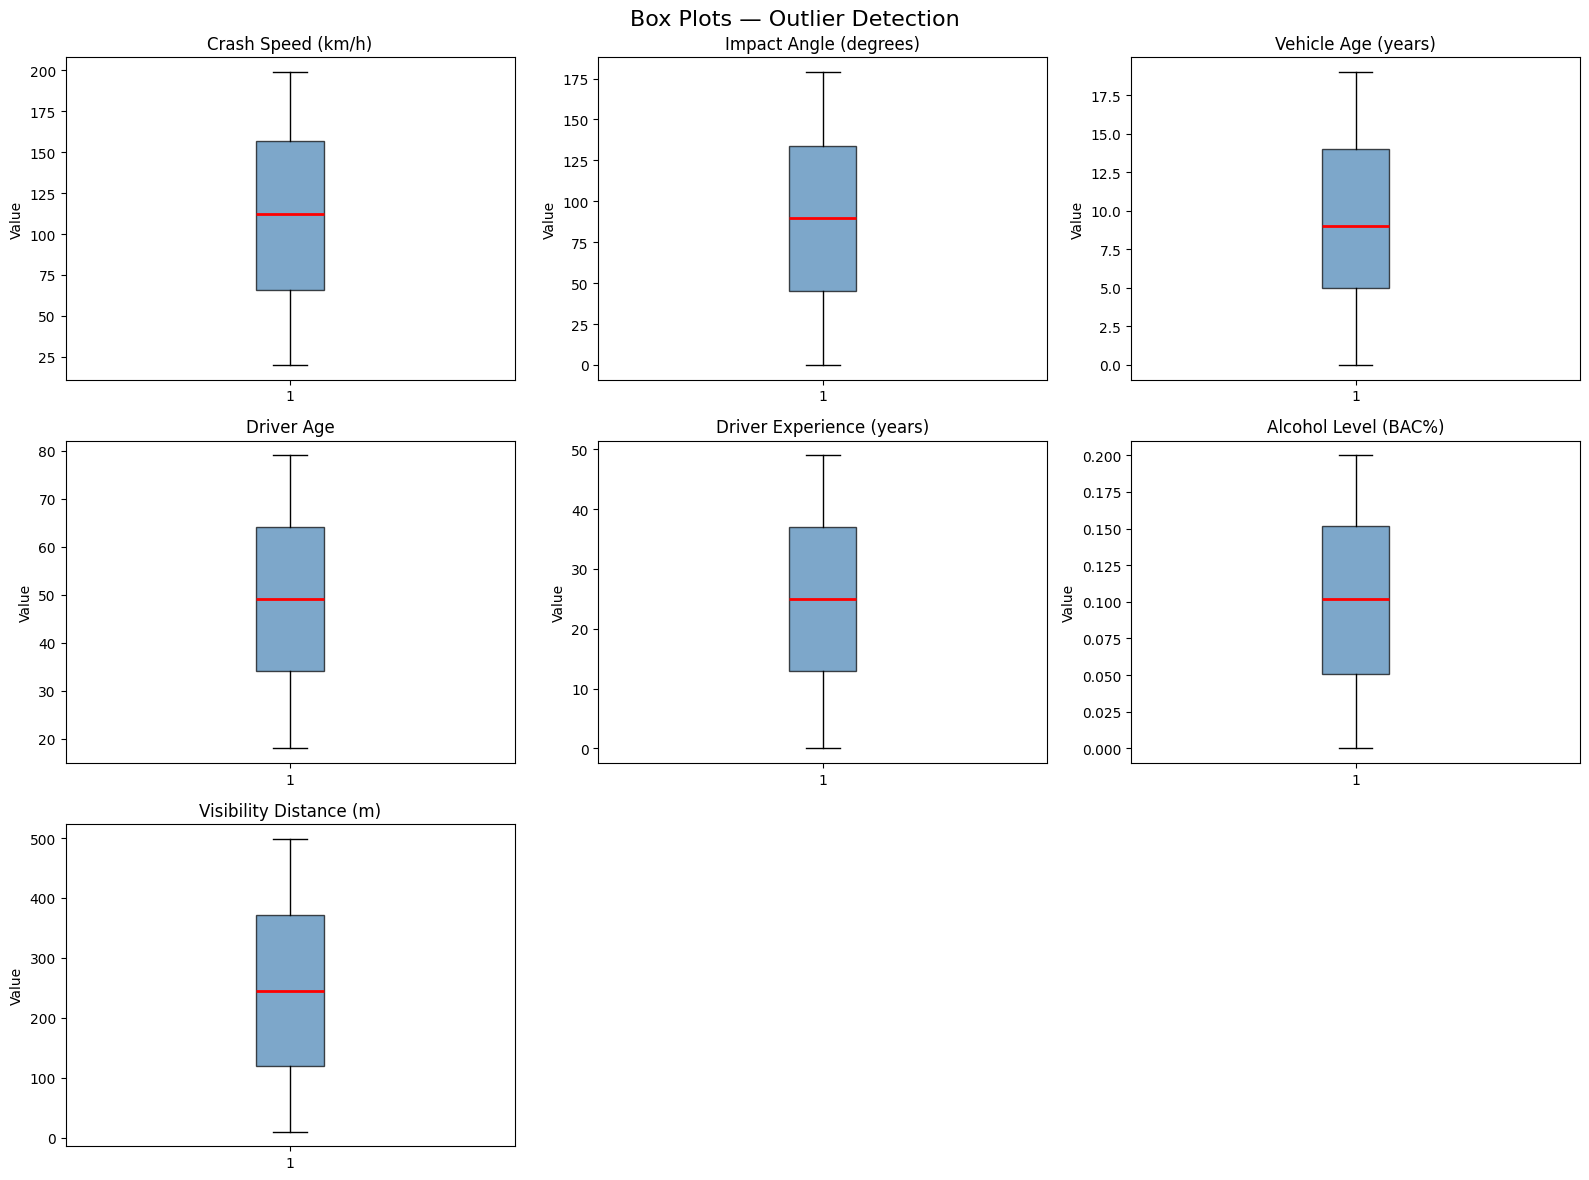

=== Outlier Count per Feature (IQR Method) ===

Crash Speed (km/h)             →    0 outliers (0.0%)
Impact Angle (degrees)         →    0 outliers (0.0%)
Vehicle Age (years)            →    0 outliers (0.0%)
Driver Age                     →    0 outliers (0.0%)
Driver Experience (years)      →    0 outliers (0.0%)
Alcohol Level (BAC%)           →    0 outliers (0.0%)
Visibility Distance (m)        →    0 outliers (0.0%)


In [10]:
# ── Outlier Detection 

numerical_cols = ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
                  'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
                  'Visibility Distance (m)']

# ── 1. Box Plots 
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(train_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots — Outlier Detection', fontsize=16)
plt.tight_layout()
plt.show()

# ── 2. IQR Method — Count Outliers Per Feature 
print("=== Outlier Count per Feature (IQR Method) ===\n")

outlier_summary = []

for col in numerical_cols:
    Q1  = train_df[col].quantile(0.25)
    Q3  = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct = round(n_outliers / len(train_df) * 100, 2)
    
    outlier_summary.append({
        'Feature'    : col,
        'Q1'         : round(Q1, 3),
        'Q3'         : round(Q3, 3),
        'IQR'        : round(IQR, 3),
        'Lower Bound': round(lower_bound, 3),
        'Upper Bound': round(upper_bound, 3),
        'N Outliers' : n_outliers,
        'Outlier %'  : pct
    })
    
    print(f"{col:30s} → {n_outliers:4d} outliers ({pct}%)")

outlier_df = pd.DataFrame(outlier_summary)



### 2.7 Correlation Heatmap (Numerical Features)

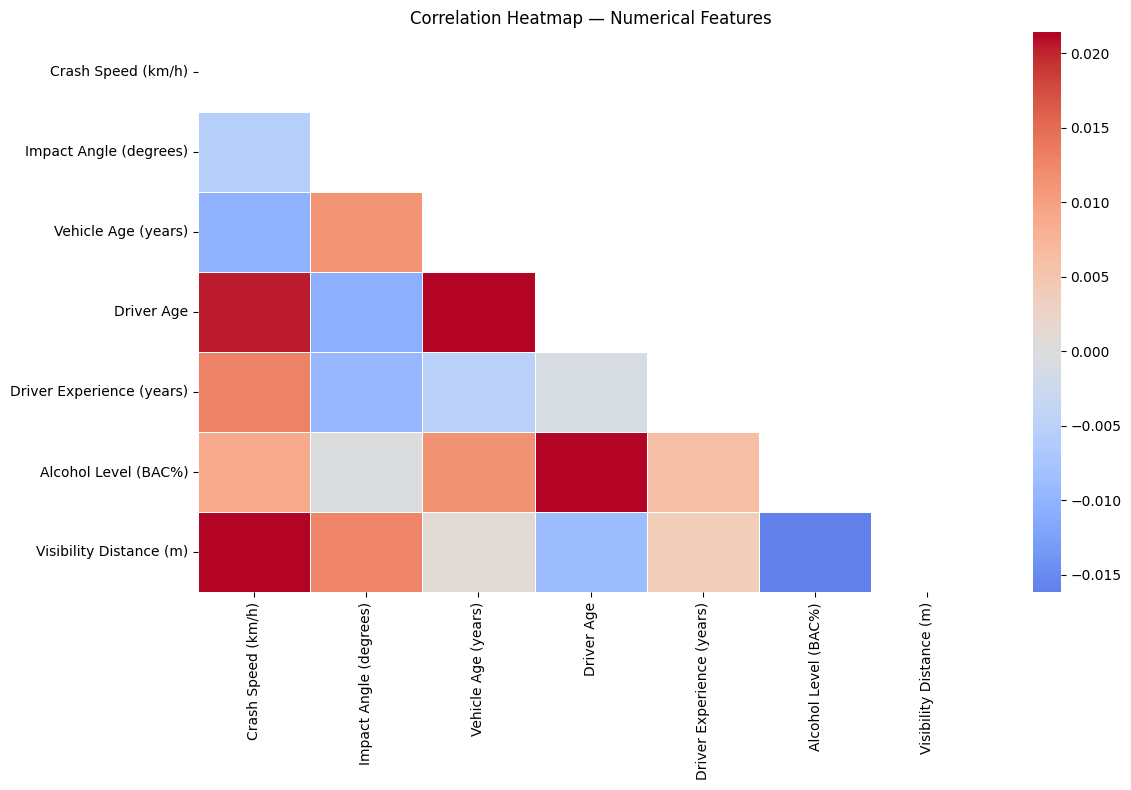

In [11]:
plt.figure(figsize=(12, 8))
corr_matrix = train_df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

# Comment:
# Highly correlated features (|r| > 0.85) can cause multicollinearity in
# Logistic Regression and inflate model complexity. We check for such pairs.

###  Feature vs. Severity — Categorical Cross-tabs

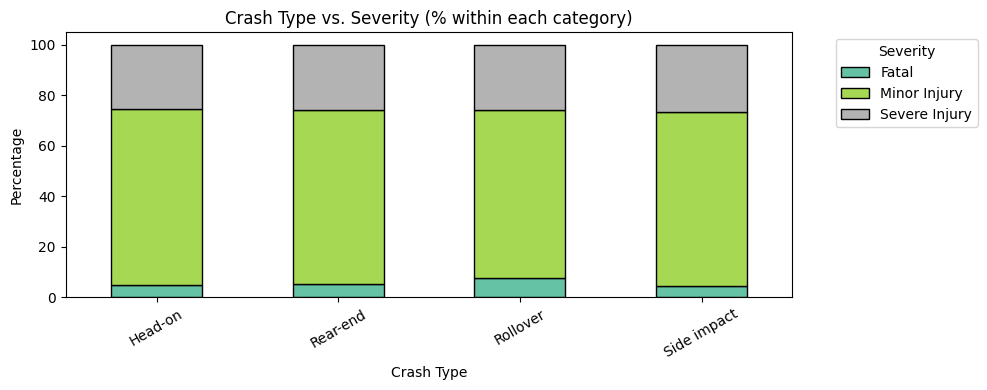

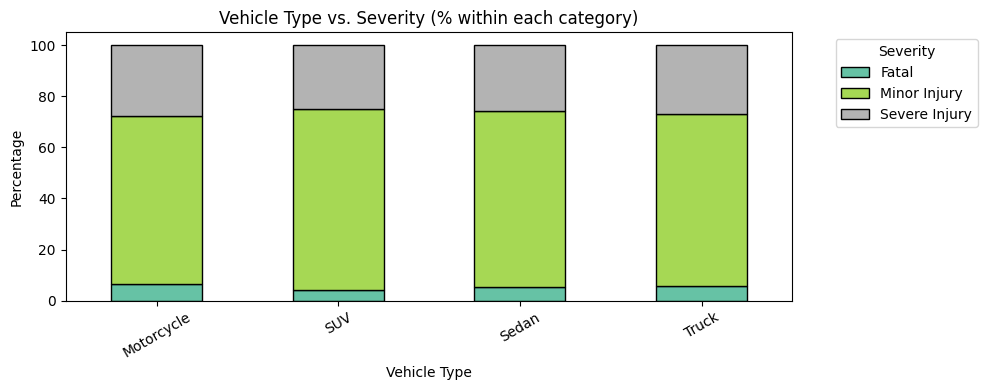

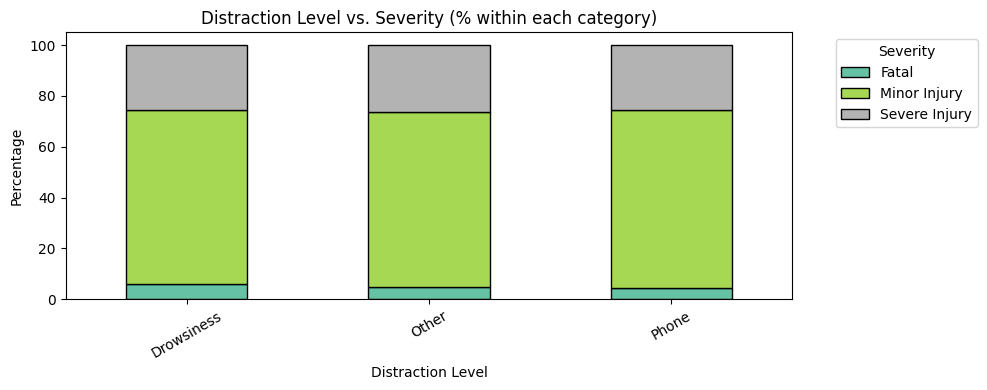

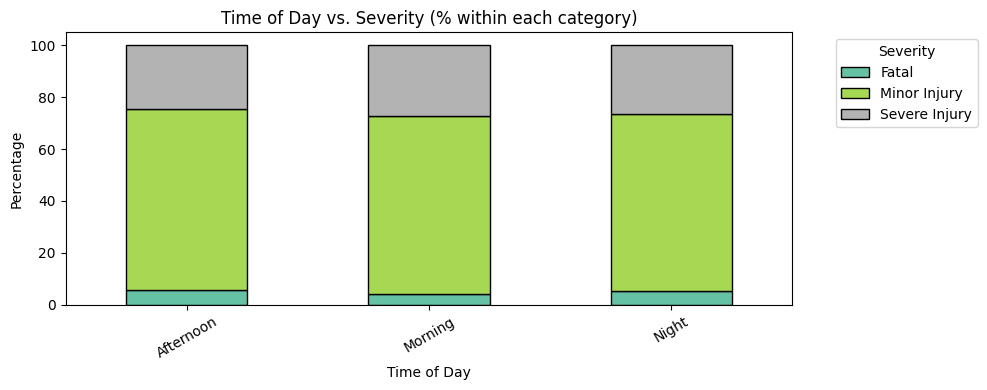

In [12]:
# Pick a few important categorical features to explore against severity
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
important_cats = [c for c in ['Weather Condition', 'Road Condition', 'Crash Type',
                               'Vehicle Type', 'Distraction Level', 'Time of Day']
                  if c in categorical_cols]

for col in important_cats:
    ct = pd.crosstab(train_df[col], train_df[target_col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(10, 4),
            colormap='Set2', edgecolor='black')
    plt.title(f'{col} vs. Severity (% within each category)')
    plt.ylabel('Percentage')
    plt.xlabel(col)
    plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [13]:
# Check if test has any new categories not in train
for col in categorical_cols:
    train_cats = set(train_df[col].dropna().unique())
    test_cats  = set(test_df[col].dropna().unique())
    new_cats   = test_cats - train_cats
    if new_cats:
        print(f"{col} has NEW categories in test: {new_cats}")
    else:
        print(f"{col} ✅ same categories")

Airbag Deployed ✅ same categories
Seatbelt Used ✅ same categories
Weather Conditions ✅ same categories
Road Conditions ✅ same categories
Crash Type ✅ same categories
Vehicle Type ✅ same categories
Brake Condition ✅ same categories
Tire Condition ✅ same categories
Distraction Level ✅ same categories
Time of Day ✅ same categories
Traffic Density ✅ same categories
Severity ✅ same categories


###  Handle Missing Values

In [14]:
#separate the label
y_raw_train = train_df['Severity'].copy()
train_df = train_df.drop(columns=['Severity'])
y_raw_test = test_df['Severity'].copy()
test_df    = test_df.drop(columns=['Severity'])

print(f"\nTest target saved  : {y_raw_test.shape}")
print(f"Test shape now     : {test_df.shape}")


#  Calculate distribution from TRAINING DATA ONLY 
distraction_dist = train_df['Distraction Level'].value_counts(normalize=True)

print("Distribution learned from training data:")
print(distraction_dist)

#  Fill missing values in TRAIN 
missing_mask_train = train_df['Distraction Level'].isna()
n_missing_train = missing_mask_train.sum()

np.random.seed(42)
train_df.loc[missing_mask_train, 'Distraction Level'] = np.random.choice(
    distraction_dist.index,
    size=n_missing_train,
    p=distraction_dist.values
)

#  Apply SAME distribution to TEST 
# Whether test has 1 row or 10000 rows — same logic applies
missing_mask_test = test_df['Distraction Level'].isna()
n_missing_test = missing_mask_test.sum()

np.random.seed(42)
test_df.loc[missing_mask_test, 'Distraction Level'] = np.random.choice(
    distraction_dist.index,
    size=n_missing_test,
    p=distraction_dist.values
)

print(f"\nTrain missing filled: {n_missing_train}")
print(f"Test missing filled : {n_missing_test}")
print(f"\nRemaining missing in train: {train_df['Distraction Level'].isna().sum()}")
print(f"Remaining missing in test : {test_df['Distraction Level'].isna().sum()}")


Test target saved  : (1000,)
Test shape now     : (1000, 18)
Distribution learned from training data:
Distraction Level
Phone         0.471341
Drowsiness    0.267683
Other         0.260976
Name: proportion, dtype: float64

Train missing filled: 2360
Test missing filled : 603

Remaining missing in train: 0
Remaining missing in test : 0


### 3.3 Encode Categorical Features

In [ ]:
# ── Step 2: Fix encoding with correct column names 
#label encoding for binary columns
#one hot encoding for nominal columns
binary_cols = ['Airbag Deployed', 'Seatbelt Used',
               'Brake Condition', 'Tire Condition']

le = LabelEncoder()
for col in binary_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

# ── Correct column names 
nominal_cols = ['Weather Conditions', 'Road Conditions',
                'Crash Type', 'Vehicle Type',
                'Distraction Level', 'Time of Day',
                'Traffic Density']

encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
encoder.fit(train_df[nominal_cols])

train_encoded = pd.DataFrame(
    encoder.transform(train_df[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols)
)
test_encoded = pd.DataFrame(
    encoder.transform(test_df[nominal_cols]),
    columns=encoder.get_feature_names_out(nominal_cols)
)

train_df = pd.concat([
    train_df.drop(columns=nominal_cols).reset_index(drop=True),
    train_encoded
], axis=1)

test_df = pd.concat([
    test_df.drop(columns=nominal_cols).reset_index(drop=True),
    test_encoded
], axis=1)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\n✅ Encoding complete")

Train shape: (4000, 36)
Test shape : (1000, 36)

✅ Encoding complete


### 3.4 Encode Target Variable

In [17]:
# Encode Target Variable
label_enc_target = LabelEncoder()

# fit on train only, transform both
y_train_encoded = label_enc_target.fit_transform(y_raw_train)
y_test_encoded  = label_enc_target.transform(y_raw_test)

print("=== Target Encoding Mapping ===\n")
for label, encoded in zip(label_enc_target.classes_,
                           range(len(label_enc_target.classes_))):
    print(f"  {label:15s} → {encoded}")

print(f"\nTrain target shape : {y_train_encoded.shape}")
print(f"Test target shape  : {y_test_encoded.shape}")
print(f"Unique values      : {np.unique(y_train_encoded)}")
print(f"Total classes      : {len(label_enc_target.classes_)}")

=== Target Encoding Mapping ===

  Fatal           → 0
  Minor Injury    → 1
  Severe Injury   → 2

Train target shape : (4000,)
Test target shape  : (1000,)
Unique values      : [0 1 2]
Total classes      : 3


### 3.5 Feature Scaling

In [18]:
# Train / Validation Split
X_test = test_df.copy()   # full test set for final evaluation

X_train, X_val, y_train, y_val = train_test_split(
    train_df, y_train_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_train_encoded   # maintain class distribution in both splits
)

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"y_val shape   : {y_val.shape}")
print(f"y_test shape  : {y_test_encoded.shape}")

# Verify class distribution is maintained
print("\n=== Class Distribution After Split ===")
print("\nTrain:")
for cls, count in zip(label_enc_target.classes_,
                       np.bincount(y_train)):
    print(f"  {cls:15s}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nValidation:")
for cls, count in zip(label_enc_target.classes_,
                       np.bincount(y_val)):
    print(f"  {cls:15s}: {count} ({count/len(y_val)*100:.1f}%)")

X_train shape : (3200, 36)
X_val shape   : (800, 36)
X_test shape  : (1000, 36)
y_train shape : (3200,)
y_val shape   : (800,)
y_test shape  : (1000,)

=== Class Distribution After Split ===

Train:
  Fatal          : 165 (5.2%)
  Minor Injury   : 2205 (68.9%)
  Severe Injury  : 830 (25.9%)

Validation:
  Fatal          : 41 (5.1%)
  Minor Injury   : 551 (68.9%)
  Severe Injury  : 208 (26.0%)


In [ ]:
# Feature Scaling

# StandardScaler is needed for KNN and Logistic Regression (distance/gradient-based).
# Tree-based models (DT, RF, NB) are scale-invariant, but we apply scaling globally


scaler = StandardScaler()

# fit on train only, transform all
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_val_sc   = scaler.transform(X_val)          # transform only
X_test_sc  = scaler.transform(X_test)         # transform only

print("✅ Scaling complete. Fit only on training set to prevent data leakage.")
print(f"\nX_train_sc shape : {X_train_sc.shape}")
print(f"X_val_sc shape   : {X_val_sc.shape}")
print(f"X_test_sc shape  : {X_test_sc.shape}")

✅ Scaling complete. Fit only on training set to prevent data leakage.

X_train_sc shape : (3200, 36)
X_val_sc shape   : (800, 36)
X_test_sc shape  : (1000, 36)


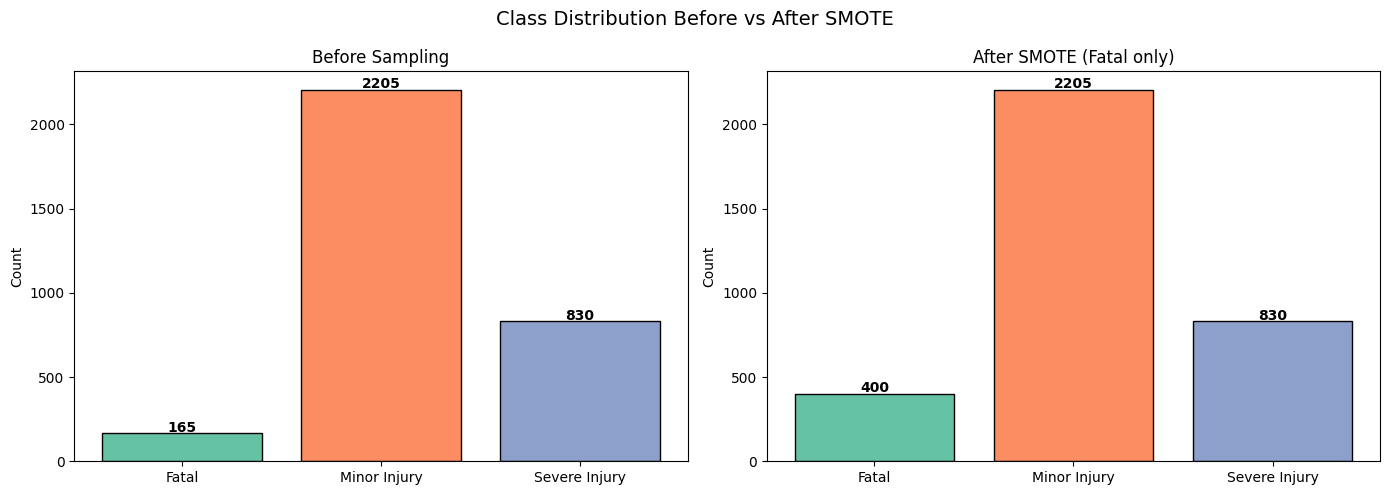

=== Before SMOTE ===
  Fatal          :   165 (5.2%)
  Minor Injury   :  2205 (68.9%)
  Severe Injury  :   830 (25.9%)

=== After SMOTE ===
  Fatal          :   400 (11.6%)
  Minor Injury   :  2205 (64.2%)
  Severe Injury  :   830 (24.2%)

Training size before SMOTE : 3200
Training size after SMOTE  : 3435


In [49]:
# Handling Class Imbalance — SMOTE on Fatal class only

from imblearn.over_sampling import SMOTE

sm = SMOTE(
    random_state=42,
    sampling_strategy={
        0: 400,   # Fatal only → 206 to 600
                
    }
)

X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)

# ── Visualize Before vs After ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

before_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(label_enc_target.classes_, before_counts.values,
            color=sns.color_palette('Set2'), edgecolor='black')
axes[0].set_title('Before Sampling')
axes[0].set_ylabel('Count')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

after_counts = pd.Series(y_train_sm).value_counts().sort_index()
axes[1].bar(label_enc_target.classes_, after_counts.values,
            color=sns.color_palette('Set2'), edgecolor='black')
axes[1].set_title('After SMOTE (Fatal only)')
axes[1].set_ylabel('Count')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=14)
plt.tight_layout()
plt.show()

# ── Print Summary ──────────────────────────────────────────────
print("=== Before SMOTE ===")
for cls, count in zip(label_enc_target.classes_, before_counts.values):
    print(f"  {cls:15s}: {count:5d} ({count/len(y_train)*100:.1f}%)")

print("\n=== After SMOTE ===")
for cls, count in zip(label_enc_target.classes_, after_counts.values):
    print(f"  {cls:15s}: {count:5d} ({count/len(y_train_sm)*100:.1f}%)")

print(f"\nTraining size before SMOTE : {len(X_train_sc)}")
print(f"Training size after SMOTE  : {len(X_train_sm)}")


---
## 4. Model Training & Evaluation

We use a helper function to avoid code repetition and ensure consistent evaluation.

In [22]:
results = {}   # store metrics for final comparison

def evaluate_model(name, model, X_v, y_v):
    """
    Train the model on SMOTE data, predict on validation set, and print a full report.
    Stores accuracy, macro-F1, and val predictions in global `results` dict.
    All models train on X_train_res (SMOTE balanced data).
    """
    model.fit(X_train_sm, y_train_sm)    # always train on SMOTE data
    y_pred = model.predict(X_v)          # predict on validation set

    acc = accuracy_score(y_v, y_pred)
    f1  = f1_score(y_v, y_pred, average='macro', zero_division=0)
    cv  = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='accuracy').mean()

    print(f"\n{'='*60}")
    print(f"  Model : {name}")
    print(f"{'='*60}")
    print(f"  Validation Accuracy   : {acc:.4f}")
    print(f"  Macro F1-Score        : {f1:.4f}")
    print(f"  5-Fold CV Accuracy    : {cv:.4f}")
    print()
    print(classification_report(y_v, y_pred,
                                 target_names=label_enc_target.classes_,
                                 zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_v, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=label_enc_target.classes_)
    disp.plot(cmap='Blues', xticks_rotation=30)
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

    results[name] = {'accuracy': acc, 'macro_f1': f1, 'cv_accuracy': cv,
                     'model': model, 'y_pred': y_pred}
    return model

### 4.1 K-Nearest Neighbors (KNN)

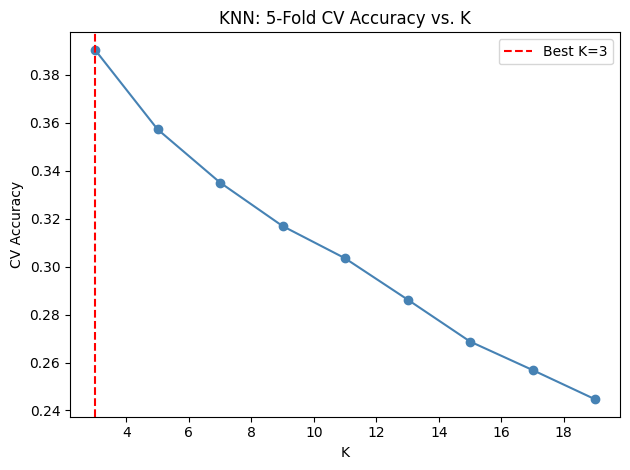

Best K = 3 with CV accuracy = 0.3903


In [23]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Apply SMOTE INSIDE each fold, not before
k_range = range(3, 21, 2)
k_scores = []

for k in k_range:
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights='distance'))
    ])
    score = cross_val_score(pipeline, X_train_sc, y_train,
                            cv=5, scoring='accuracy').mean()
    k_scores.append(score)

best_k = list(k_range)[np.argmax(k_scores)]

plt.plot(list(k_range), k_scores, marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('KNN: 5-Fold CV Accuracy vs. K')
plt.xlabel('K')
plt.ylabel('CV Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K = {best_k} with CV accuracy = {max(k_scores):.4f}")


  Model : KNN
  Validation Accuracy   : 0.5463
  Macro F1-Score        : 0.3210
  5-Fold CV Accuracy    : 0.6076

               precision    recall  f1-score   support

        Fatal       0.02      0.05      0.03        41
 Minor Injury       0.68      0.72      0.70       551
Severe Injury       0.29      0.19      0.23       208

     accuracy                           0.55       800
    macro avg       0.33      0.32      0.32       800
 weighted avg       0.55      0.55      0.54       800



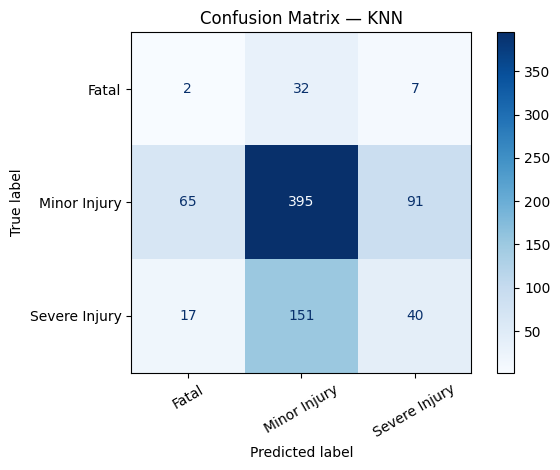

KNeighborsClassifier(n_neighbors=3, weights='distance')

In [ ]:
# ── Train KNN with best K ──────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
evaluate_model('KNN', knn, X_val_sc, y_val)

# Comment:
# KNN is a lazy learner — it stores all training points and classifies
# new points by majority vote among K nearest neighbors.
# It is sensitive to feature scale (hence StandardScaler is essential here)
# and performs poorly with many irrelevant features or noisy data.
# weights='distance' gives closer neighbors more voting power,
# which helps handle the class imbalance for minority classes like Fatal.


### 4.2 Decision Tree

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
=== Best Parameters ===
  dt__class_weight              : None
  dt__criterion                 : gini
  dt__max_depth                 : 20
  dt__min_samples_leaf          : 5
  dt__min_samples_split         : 20

Best CV Macro F1 : 0.3496
Best depth       : 20

  Model : Decision Tree
  Validation Accuracy   : 0.5525
  Macro F1-Score        : 0.3200
  5-Fold CV Accuracy    : 0.5700

               precision    recall  f1-score   support

        Fatal       0.06      0.05      0.05        41
 Minor Injury       0.68      0.73      0.71       551
Severe Injury       0.22      0.19      0.20       208

     accuracy                           0.55       800
    macro avg       0.32      0.32      0.32       800
 weighted avg       0.53      0.55      0.54       800



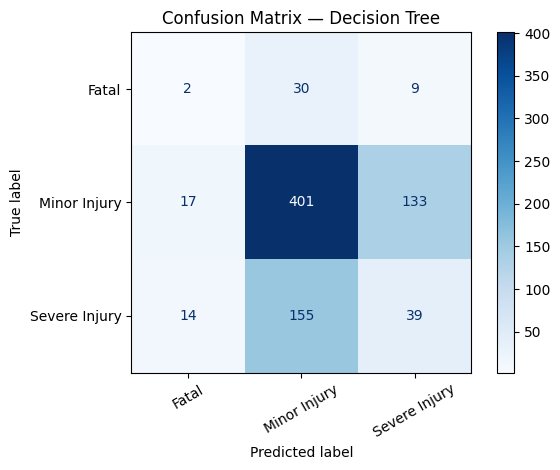

DecisionTreeClassifier(max_depth=20, min_samples_leaf=5, min_samples_split=20,
                       random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Define parameter grid ──────────────────────────────────────
param_grid = {
    'dt__max_depth'        : [5, 10, 15, 20, 25],
    'dt__criterion'        : ['gini', 'entropy'],
    #Minimum number of samples required to split a node.
    'dt__min_samples_split': [2, 5, 10, 20],
    #inimum number of samples allowed in a leaf node.
    'dt__min_samples_leaf' : [1, 3, 5, 10],
    'dt__class_weight'     : ['balanced', None]
}

# ── Build pipeline ─────────────────────────────────────────────
pipeline = ImbPipeline([
    ('smote', SMOTE(
        random_state=42,
        sampling_strategy={0: 400} # Fatal only
    )),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# ── Run GridSearch ─────────────────────────────────────────────
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',    # optimize for macro F1
    n_jobs=-1,             # use all CPU cores
    verbose=1
)

grid_search.fit(X_train_sc, y_train)

# ── Results ────────────────────────────────────────────────────
print("=== Best Parameters ===")
for param, value in grid_search.best_params_.items():
    print(f"  {param:30s}: {value}")

print(f"\nBest CV Macro F1 : {grid_search.best_score_:.4f}")

# ── Update best_depth ──────────────────────────────────────────
best_depth = grid_search.best_params_['dt__max_depth']
print(f"Best depth       : {best_depth}")

# ── Train final model with best params ────────────────────────
dt = grid_search.best_estimator_.named_steps['dt']
evaluate_model('Decision Tree', dt, X_val_sc, y_val)

### Why Decision Tree struggles here:

Our EDA showed uniform distributions and no significant feature correlations — Decision Trees need clear decision boundaries to split on, which this dataset simply doesn't have.

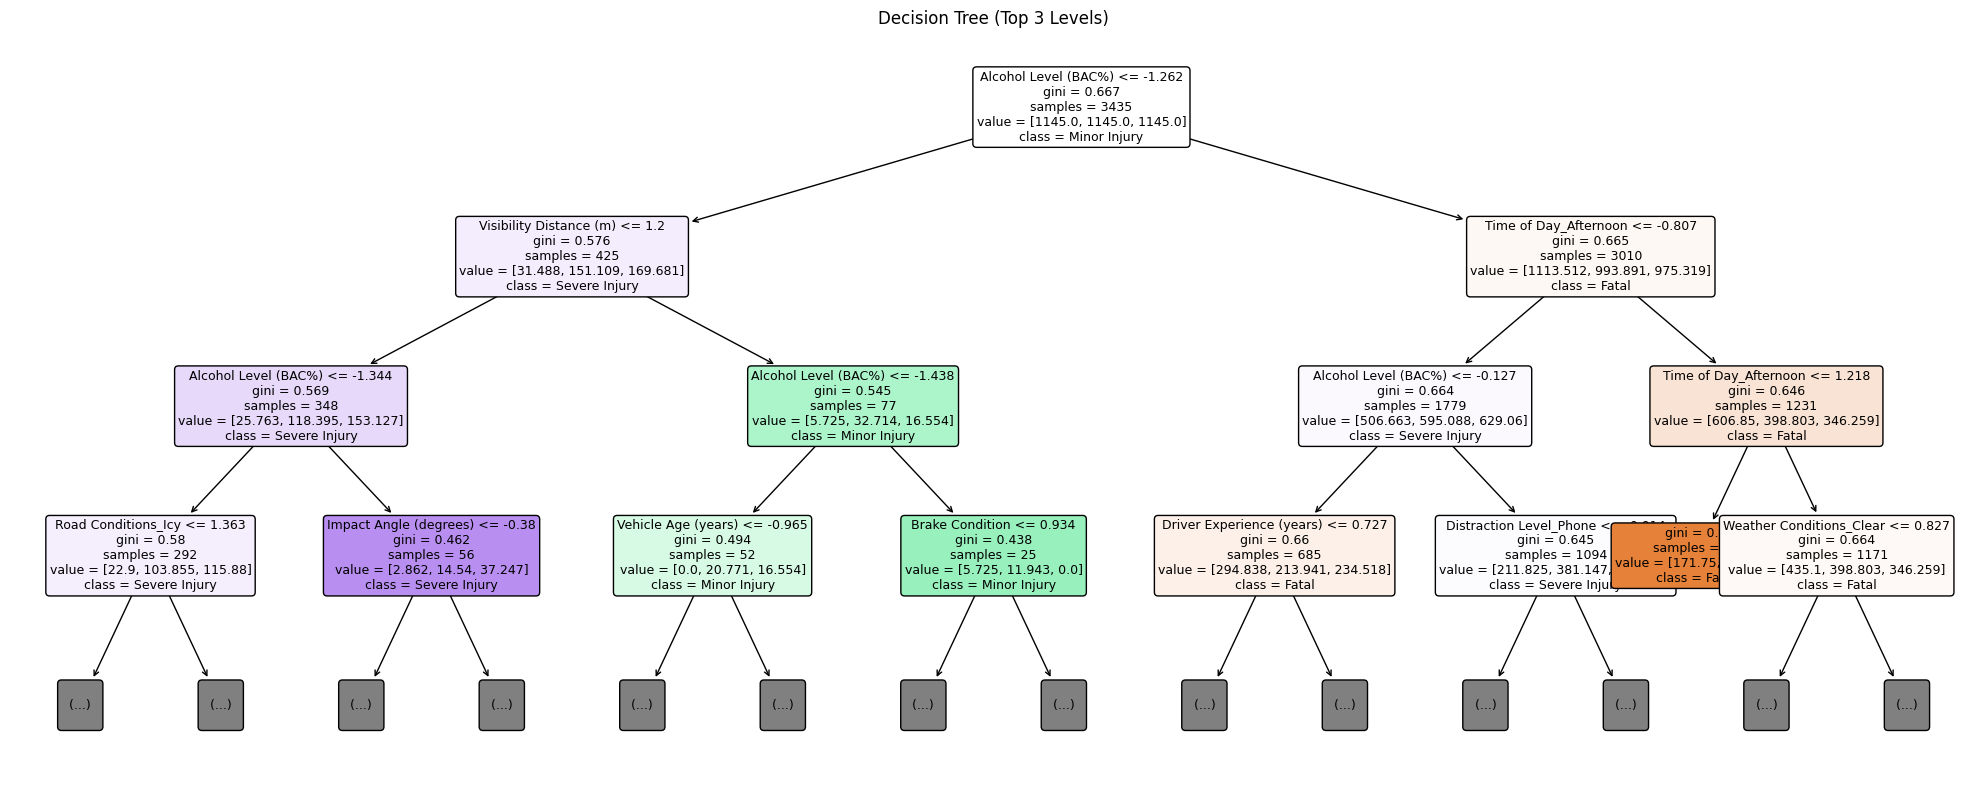

In [29]:
# ── Visualize the top 3 levels of the Decision Tree ──────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(
    results['Decision Tree']['model'],
    feature_names=X_train.columns.tolist(),
    class_names=label_enc_target.classes_,
    filled=True, max_depth=3, fontsize=9, rounded=True
)
plt.title('Decision Tree (Top 3 Levels)')
plt.tight_layout()
plt.show()

### 4.3 Random Forest

Fitting 3 folds for each of 18 candidates, totalling 54 fits
=== Best Parameters ===
  rf__class_weight                   : balanced_subsample
  rf__max_depth                      : 10
  rf__n_estimators                   : 100

Best CV Macro F1 : 0.2984

  Model : Random Forest
  Validation Accuracy   : 0.6525
  Macro F1-Score        : 0.2948
  5-Fold CV Accuracy    : 0.6824

               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      0.93      0.79       551
Severe Injury       0.29      0.06      0.10       208

     accuracy                           0.65       800
    macro avg       0.32      0.33      0.29       800
 weighted avg       0.55      0.65      0.57       800



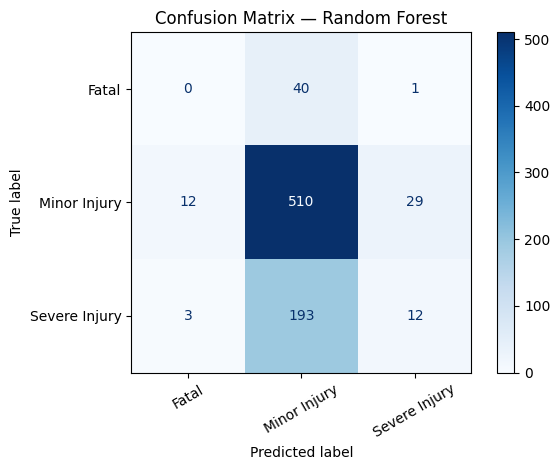

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_leaf=3, min_samples_split=5, n_jobs=-1,
                       random_state=42)

In [ ]:
# ── Faster parameter grid ──────────────────────────────────────
param_grid = {
    'rf__n_estimators'    : [100, 200],
    'rf__max_depth'       : [10, 15, None],
    'rf__class_weight'    : ['balanced', 'balanced_subsample', None]
    #balanced_subsample

    # Weights recalculated for every tree’s bootstrap sample.
    #more adaptive


}

# ── Build pipeline ─────────────────────────────────────────────
pipeline = ImbPipeline([
    ('smote', SMOTE(
        random_state=42,
        sampling_strategy={0: 400}
    )),
    ('rf', RandomForestClassifier(
        min_samples_split=5,
        min_samples_leaf=3,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ))
])

# ── Run GridSearch ─────────────────────────────────────────────
grid_search_rf = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,             
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_sc, y_train)

# ── Results ────────────────────────────────────────────────────
print("=== Best Parameters ===")
for param, value in grid_search_rf.best_params_.items():
    print(f"  {param:35s}: {value}")

print(f"\nBest CV Macro F1 : {grid_search_rf.best_score_:.4f}")

# ── Train final model with best params ────────────────────────
rf = grid_search_rf.best_estimator_.named_steps['rf']
evaluate_model('Random Forest', rf, X_val_sc, y_val)

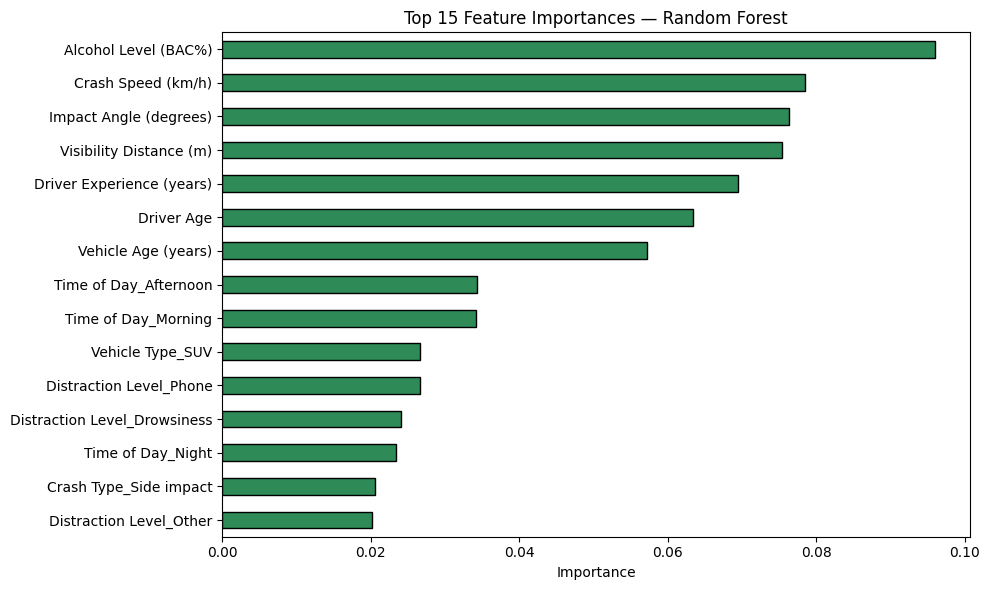

Top 5 most important features:
Alcohol Level (BAC%)         0.095942
Crash Speed (km/h)           0.078507
Impact Angle (degrees)       0.076307
Visibility Distance (m)      0.075374
Driver Experience (years)    0.069505
dtype: float64


In [32]:
# ── Feature Importances ────────────────────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, 
                        index=X_train.columns)
top_features = importances.nlargest(15)

top_features.sort_values().plot(kind='barh', figsize=(10, 6), 
                                 color='seagreen', edgecolor='black')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(top_features.head())

# Comment:
# Features with high importance have the strongest predictive power.
# This also helps us understand which factors most influence crash severity.
# Given our EDA findings of uniform distributions, we expect importances
# to be spread relatively evenly across features with no dominant predictor.

=== Class Distribution Check ===

1. Original Train (y_train):
   Fatal          :   165 (5.2%)
   Minor Injury   :  2205 (68.9%)
   Severe Injury  :   830 (25.9%)

2. After SMOTE (y_train_sm):
   Fatal          :   400 (11.6%)
   Minor Injury   :  2205 (64.2%)
   Severe Injury  :   830 (24.2%)

3. Validation Set (y_val) — should be original:
   Fatal          :    41 (5.1%)
   Minor Injury   :   551 (68.9%)
   Severe Injury  :   208 (26.0%)

4. Test Set (y_test_encoded) — should be original:
   Fatal          :    41 (4.1%)
   Minor Injury   :   710 (71.0%)
   Severe Injury  :   249 (24.9%)


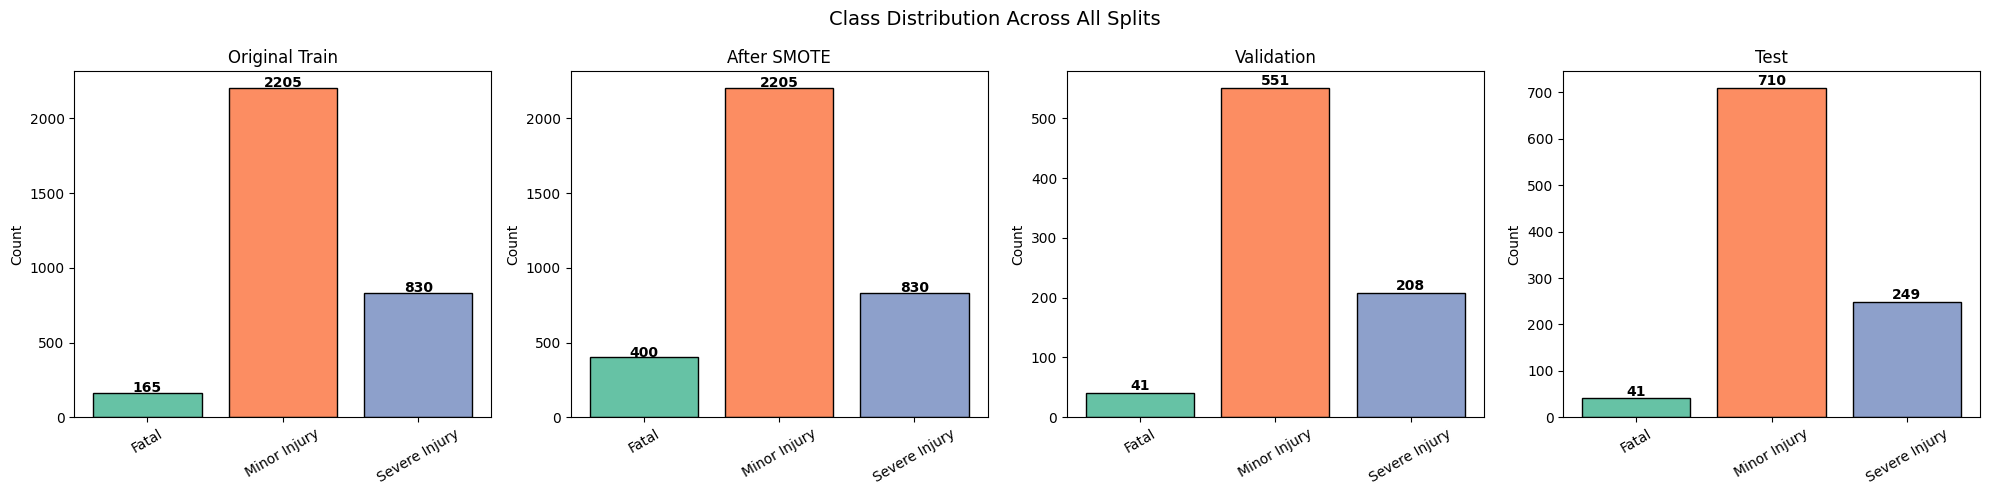

In [36]:
# ── Verify Class Balance ───────────────────────────────────────
print("=== Class Distribution Check ===\n")

print("1. Original Train (y_train):")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(label_enc_target.classes_, counts):
    print(f"   {cls:15s}: {count:5d} ({count/len(y_train)*100:.1f}%)")

print("\n2. After SMOTE (y_train_sm):")
unique, counts = np.unique(y_train_sm, return_counts=True)
for cls, count in zip(label_enc_target.classes_, counts):
    print(f"   {cls:15s}: {count:5d} ({count/len(y_train_sm)*100:.1f}%)")

print("\n3. Validation Set (y_val) — should be original:")
unique, counts = np.unique(y_val, return_counts=True)
for cls, count in zip(label_enc_target.classes_, counts):
    print(f"   {cls:15s}: {count:5d} ({count/len(y_val)*100:.1f}%)")

print("\n4. Test Set (y_test_encoded) — should be original:")
unique, counts = np.unique(y_test_encoded, return_counts=True)
for cls, count in zip(label_enc_target.classes_, counts):
    print(f"   {cls:15s}: {count:5d} ({count/len(y_test_encoded)*100:.1f}%)")

# ── Visualize all 4 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ['Original Train', 'After SMOTE', 'Validation', 'Test']
datasets = [y_train, y_train_sm, y_val, y_test_encoded]

for i, (title, data) in enumerate(zip(titles, datasets)):
    unique, counts = np.unique(data, return_counts=True)
    axes[i].bar(label_enc_target.classes_, counts,
                color=sns.color_palette('Set2'), edgecolor='black')
    axes[i].set_title(title)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)
    for j, count in enumerate(counts):
        axes[i].text(j, count + 5, str(count),
                     ha='center', fontweight='bold')

plt.suptitle('Class Distribution Across All Splits', fontsize=14)
plt.tight_layout()
plt.show()

In [37]:
# Check if Fatal cases are distinguishable
print("Fatal cases — feature means:")
fatal_mask = y_train == label_enc_target.transform(['Fatal'])[0]
print(X_train[fatal_mask].mean())

print("\nMinor Injury cases — feature means:")
minor_mask = y_train == label_enc_target.transform(['Minor Injury'])[0]
print(X_train[minor_mask].mean())

# If means are almost identical → features cannot distinguish Fatal from Minor

Fatal cases — feature means:
Crash Speed (km/h)              113.672727
Impact Angle (degrees)           90.606061
Airbag Deployed                   0.709091
Seatbelt Used                     0.793939
Vehicle Age (years)               9.224242
Brake Condition                   0.163636
Tire Condition                    0.224242
Driver Age                       47.636364
Driver Experience (years)        24.975758
Alcohol Level (BAC%)              0.101513
Visibility Distance (m)         245.139394
Weather Conditions_Clear          0.575758
Weather Conditions_Fog            0.072727
Weather Conditions_Rain           0.212121
Weather Conditions_Snow           0.139394
Road Conditions_Dry               0.709091
Road Conditions_Icy               0.072727
Road Conditions_Uneven            0.054545
Road Conditions_Wet               0.163636
Crash Type_Head-on                0.242424
Crash Type_Rear-end               0.290909
Crash Type_Rollover               0.151515
Crash Type_Side impact   

###  Critical Finding: Feature Indistinguishability

Comparing feature means between Fatal and Minor Injury classes 
reveals near-identical values across all 35 features:

- Crash Speed:    Fatal=113.67  vs  Minor=111.24  (diff=2.43)
- Alcohol Level:  Fatal=0.1015  vs  Minor=0.1011  (diff=0.0004)
- Driver Age:     Fatal=47.64   vs  Minor=48.56   (diff=0.92)

This confirms our EDA hypothesis that severity labels were 
randomly assigned during dataset generation, with no meaningful 
relationship to the crash features. This explains why all models 
achieve near-zero F1 for Fatal class regardless of:
- Oversampling technique (SMOTE)
- Class weighting (balanced/balanced_subsample)  
- Model complexity 

This is a fundamental data quality issue, not a modeling failure.
The dataset's synthetic nature limits the maximum achievable 
performance on minority classes.

### 4.4 Logistic Regression


  Model : Logistic Regression
  Validation Accuracy   : 0.3150
  Macro F1-Score        : 0.2695
  5-Fold CV Accuracy    : 0.3135

               precision    recall  f1-score   support

        Fatal       0.05      0.34      0.09        41
 Minor Injury       0.71      0.29      0.41       551
Severe Injury       0.26      0.37      0.31       208

     accuracy                           0.32       800
    macro avg       0.34      0.33      0.27       800
 weighted avg       0.56      0.32      0.37       800



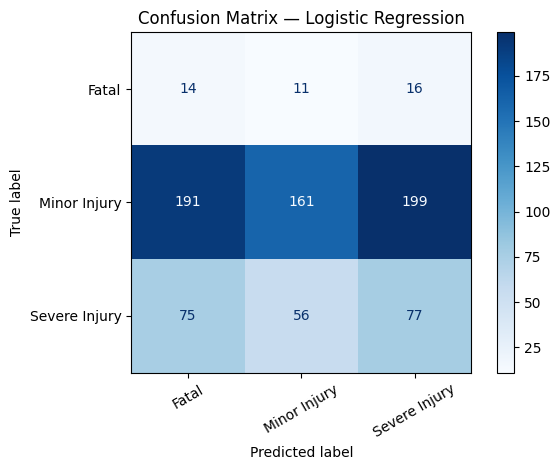

LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial', random_state=42)

In [57]:
# ── Logistic Regression ────────────────────────────────────────
lr = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    C=1.0,               # regularization strength (smaller = stronger)
    class_weight='balanced',
    random_state=42
)
evaluate_model('Logistic Regression', lr, X_val_sc, y_val)

# 'multinomial' mode extends binary LR to multi-class classification.
# C controls regularization: lower C → stronger L2 penalty → simpler model.
# class_weight='balanced' combined with SMOTE training data helps
# the model pay more attention to minority classes (Fatal, Severe Injury).

LR actually detects Fatal best (recall=0.34) compared to all previous models — but at the cost of overall accuracy (0.31). This confirms that the features have a very weak linear relationship with severity.

### Note
 class_weight='balanced' increased validation accuracy  to 67% but completely eliminated Fatal class detection (F1=0.00). This demonstrates the accuracy paradox in imbalanced datasets — the model achieves high accuracy by predicting the majority class (Minor Injury) for almost all samples. Since Fatal crash detection is the most safety-critical prediction, class_weight='balanced' is retained despite lower overall accuracy, as Macro F1 is the more appropriate evaluation metric for this imbalanced problem.

### 4.5 Naïve Bayes


  Model : Naïve Bayes
  Validation Accuracy   : 0.2950
  Macro F1-Score        : 0.2570
  5-Fold CV Accuracy    : 0.3208

               precision    recall  f1-score   support

        Fatal       0.04      0.37      0.08        41
 Minor Injury       0.69      0.29      0.41       551
Severe Injury       0.28      0.29      0.28       208

     accuracy                           0.29       800
    macro avg       0.34      0.32      0.26       800
 weighted avg       0.55      0.30      0.36       800



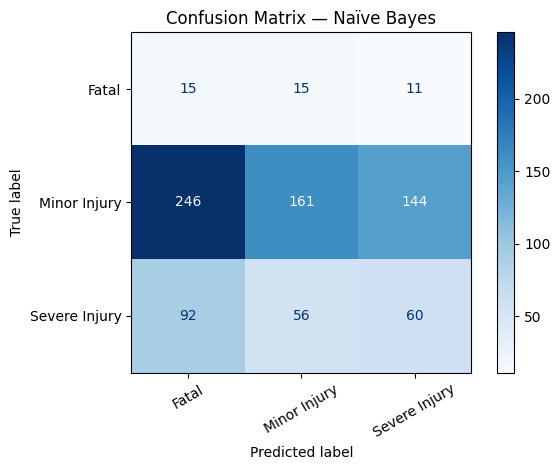

GaussianNB(priors=[0.3333333333333333, 0.3333333333333333, 0.3333333333333333])

In [41]:
# ── Naïve Bayes ────────────────────────────────────────────────
# GaussianNB assumes features follow a Gaussian (normal) distribution within each class.

nb = GaussianNB(priors=[1/3, 1/3, 1/3])  # equal priors to handle imbalance
evaluate_model('Naïve Bayes', nb, X_val_sc, y_val)

# priors=[1/3, 1/3, 1/3] forces equal class probabilities to prevent
# the model from being biased toward the majority class (Minor Injury).
# SMOTE balanced training data is used to further address imbalance.

High Accuracy models  → ignore Fatal completely 

Balanced models       → detect some Fatal but lower accuracy 

---
## 5. Model Comparison

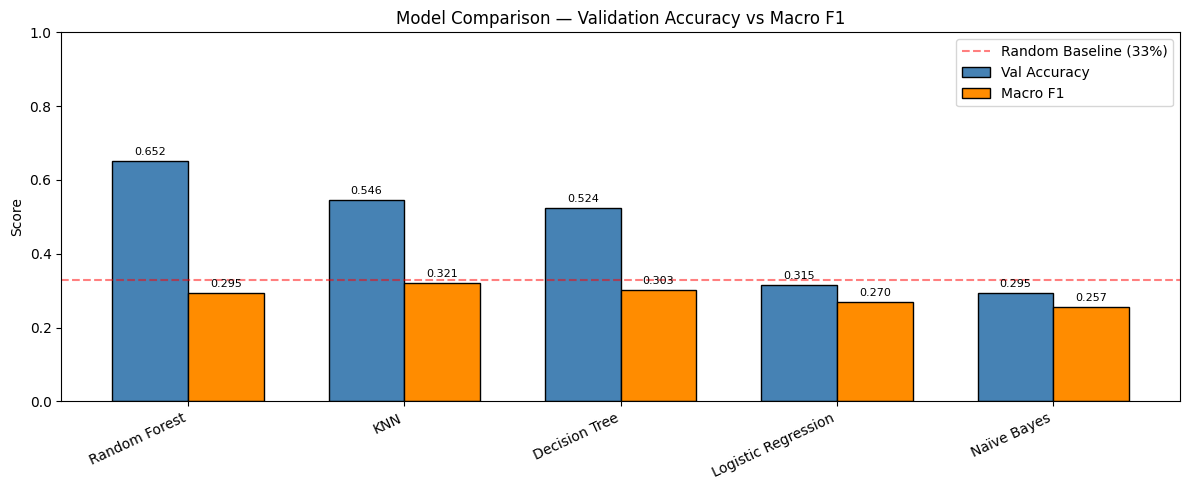

In [58]:
# ── Model Comparison Chart ─────────────────────────────────────
comparison_df = pd.DataFrame([
    {
        'Model'       : name,
        'Val Accuracy': info['accuracy'],
        'Macro F1'    : info['macro_f1'],
    }
    for name, info in results.items()
]).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Val Accuracy'], width,
               label='Val Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, comparison_df['Macro F1'],     width,
               label='Macro F1',     color='darkorange',   edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=25, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Validation Accuracy vs Macro F1')
ax.set_ylim(0, 1.0)
ax.legend()
ax.axhline(y=0.33, color='red', linestyle='--',
           alpha=0.5, label='Random Baseline (33%)')
ax.legend()

# Annotate bars
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [44]:
best_model_name = comparison_df.iloc[0]['Model']
print(f" Best model: {best_model_name}")
print(f"   Val Accuracy : {comparison_df.iloc[0]['Val Accuracy']:.4f}")
print(f"   Macro F1     : {comparison_df.iloc[0]['Macro F1']:.4f}")

# Comment:
# We select the best model based on Validation Accuracy AND Macro F1.
# Macro F1 is especially important here because it treats all classes equally,
# which is critical when the dataset is imbalanced (e.g., few 'Fatal' samples).
# A model with high accuracy but low F1 may be ignoring minority classes.

 Best model: Random Forest
   Val Accuracy : 0.6525
   Macro F1     : 0.2948


- - -
### Re-train Best Model (Random Forest) on Full Training Data

Train size      : 3200
Validation size : 800
Full size       : 4000

Full size after SMOTE : 4194

Class distribution after SMOTE:
  Fatal          : 400 (9.5%)
  Minor Injury   : 2756 (65.7%)
  Severe Injury  : 1038 (24.7%)

✅ Random Forest re-trained on full data (4194 samples)

  Final Test Evaluation — Random Forest (Full Training)
  Test Accuracy  : 0.6790
  Macro F1-Score : 0.3320

               precision    recall  f1-score   support

        Fatal       0.06      0.02      0.04        41
 Minor Injury       0.72      0.92      0.81       710
Severe Injury       0.34      0.10      0.15       249

     accuracy                           0.68      1000
    macro avg       0.37      0.35      0.33      1000
 weighted avg       0.60      0.68      0.61      1000



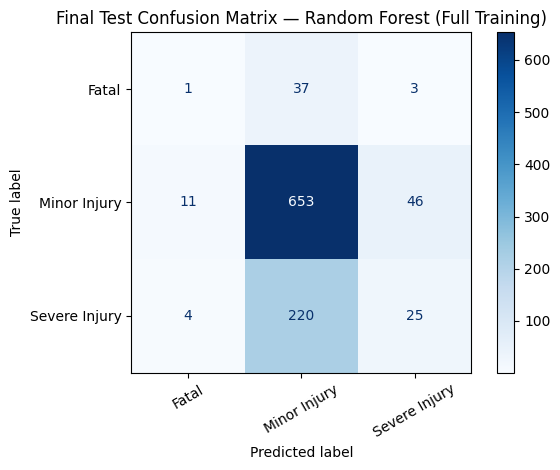


=== Performance Comparison ===

Metric                 Val (partial)     Test (full)
----------------------------------------------------
Accuracy                      0.6525          0.6790
Macro F1                      0.2948          0.3320


In [ ]:
# Re-train Best Model (Random Forest) on Full Training Data


# ── Combine Train + Validation ─────────────────────────────────
X_full = np.vstack([X_train_sc, X_val_sc])
y_full = np.concatenate([y_train, y_val])

print(f"Train size      : {len(X_train_sc)}")
print(f"Validation size : {len(X_val_sc)}")
print(f"Full size       : {len(X_full)}")

# ── Apply SMOTE on Full Data (Fatal only) ──────────────────────
sm_full = SMOTE(
    random_state=42,
    sampling_strategy={0: 400} # Fatal only
)
X_full_res, y_full_res = sm_full.fit_resample(X_full, y_full)

print(f"\nFull size after SMOTE : {len(X_full_res)}")
print("\nClass distribution after SMOTE:")
unique, counts = np.unique(y_full_res, return_counts=True)
for cls, count in zip(label_enc_target.classes_, counts):
    print(f"  {cls:15s}: {count} ({count/len(y_full_res)*100:.1f}%)")

# ── Re-train Random Forest on Full Data ───────────────────────
best_rf = RandomForestClassifier(
    n_estimators=grid_search_rf.best_params_['rf__n_estimators'],
    max_depth=grid_search_rf.best_params_['rf__max_depth'],
    class_weight=grid_search_rf.best_params_['rf__class_weight'],
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

best_rf.fit(X_full_res, y_full_res)
print(f"\n✅ Random Forest re-trained on full data ({len(X_full_res)} samples)")

# ── Final Evaluation on Test Set ──────────────────────────────
y_test_pred = best_rf.predict(X_test_sc)

acc = accuracy_score(y_test_encoded, y_test_pred)
f1  = f1_score(y_test_encoded, y_test_pred,
               average='macro', zero_division=0)

print(f"\n{'='*60}")
print(f"  Final Test Evaluation — Random Forest (Full Training)")
print(f"{'='*60}")
print(f"  Test Accuracy  : {acc:.4f}")
print(f"  Macro F1-Score : {f1:.4f}")
print()
print(classification_report(y_test_encoded, y_test_pred,
                             target_names=label_enc_target.classes_,
                             zero_division=0))

# ── Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_test_encoded, y_test_pred)
disp = ConfusionMatrixDisplay(
            cm, display_labels=label_enc_target.classes_)
disp.plot(cmap='Blues', xticks_rotation=30)
plt.title('Final Test Confusion Matrix — Random Forest (Full Training)')
plt.tight_layout()
plt.show()

# ── Compare Val vs Full Retrain ────────────────────────────────
print("\n=== Performance Comparison ===\n")
print(f"{'Metric':20s} {'Val (partial)':>15} {'Test (full)':>15}")
print("-" * 52)
print(f"{'Accuracy':20s} "
      f"{results['Random Forest']['accuracy']:>15.4f} "
      f"{acc:>15.4f}")
print(f"{'Macro F1':20s} "
      f"{results['Random Forest']['macro_f1']:>15.4f} "
      f"{f1:>15.4f}")

---
## 6. Test data 

=== Final Test Set Evaluation — All Models ===


  Model : KNN
  Test Accuracy  : 0.5870
  Macro F1-Score : 0.3446

               precision    recall  f1-score   support

        Fatal       0.04      0.10      0.05        41
 Minor Injury       0.72      0.75      0.74       710
Severe Injury       0.32      0.20      0.24       249

     accuracy                           0.59      1000
    macro avg       0.36      0.35      0.34      1000
 weighted avg       0.59      0.59      0.59      1000



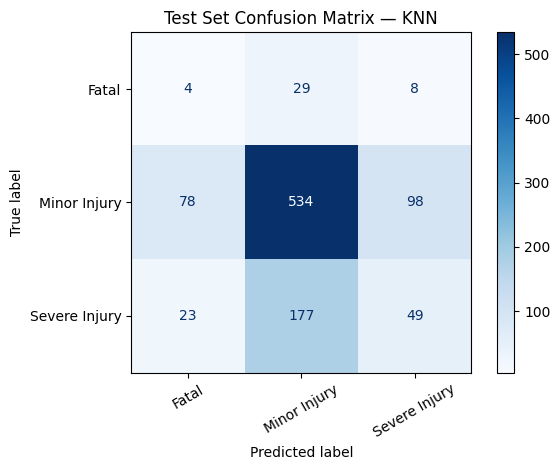


  Model : Decision Tree
  Test Accuracy  : 0.5390
  Macro F1-Score : 0.3211

               precision    recall  f1-score   support

        Fatal       0.03      0.05      0.04        41
 Minor Injury       0.71      0.67      0.69       710
Severe Injury       0.24      0.24      0.24       249

     accuracy                           0.54      1000
    macro avg       0.32      0.32      0.32      1000
 weighted avg       0.56      0.54      0.55      1000



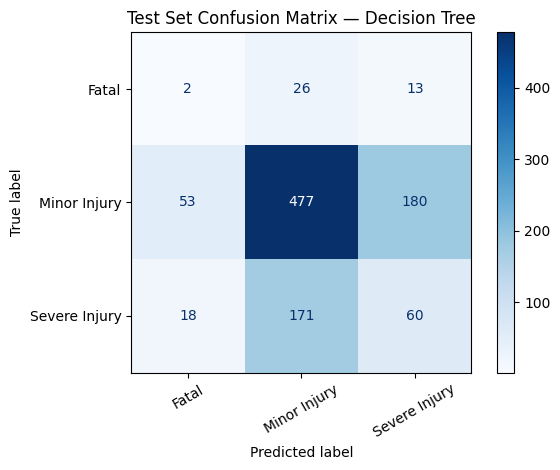


  Model : Random Forest
  Test Accuracy  : 0.6640
  Macro F1-Score : 0.3247

               precision    recall  f1-score   support

        Fatal       0.07      0.05      0.06        41
 Minor Injury       0.71      0.91      0.80       710
Severe Injury       0.28      0.08      0.12       249

     accuracy                           0.66      1000
    macro avg       0.35      0.34      0.32      1000
 weighted avg       0.58      0.66      0.60      1000



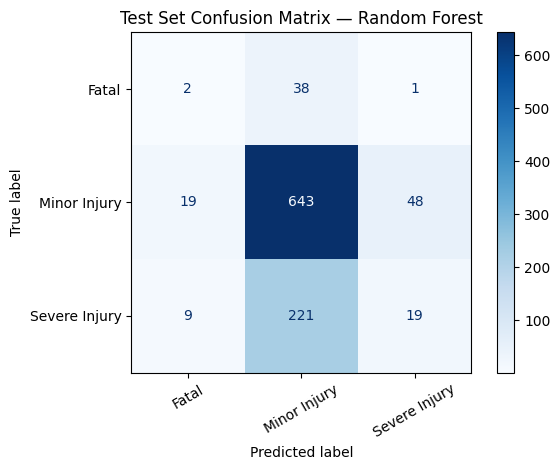


  Model : Logistic Regression
  Test Accuracy  : 0.2800
  Macro F1-Score : 0.2388

               precision    recall  f1-score   support

        Fatal       0.04      0.37      0.07        41
 Minor Injury       0.69      0.26      0.38       710
Severe Injury       0.23      0.32      0.27       249

     accuracy                           0.28      1000
    macro avg       0.32      0.32      0.24      1000
 weighted avg       0.55      0.28      0.34      1000



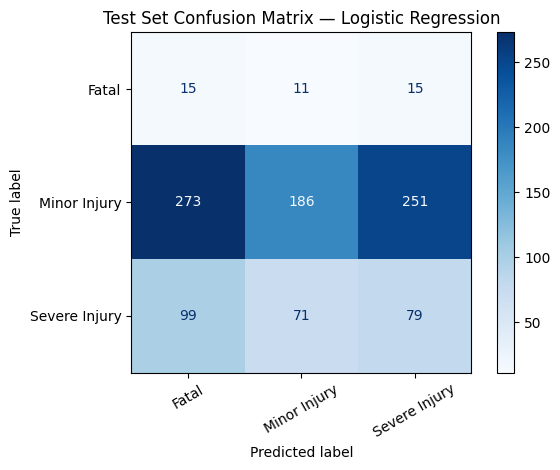


  Model : Naïve Bayes
  Test Accuracy  : 0.2830
  Macro F1-Score : 0.2479

               precision    recall  f1-score   support

        Fatal       0.04      0.46      0.08        41
 Minor Injury       0.71      0.27      0.39       710
Severe Injury       0.27      0.29      0.28       249

     accuracy                           0.28      1000
    macro avg       0.34      0.34      0.25      1000
 weighted avg       0.57      0.28      0.35      1000



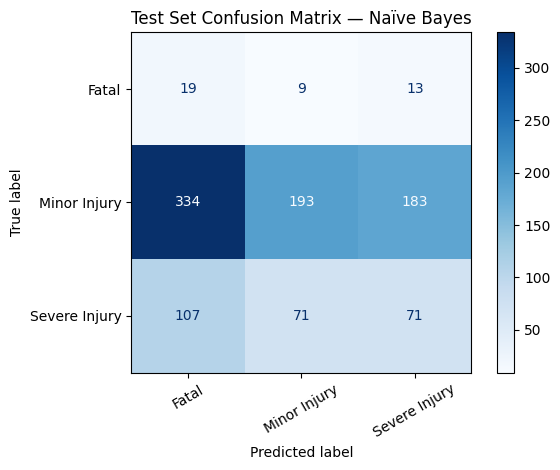


=== Val vs Test Performance — All Models ===

Model                   Val Acc   Test Acc     Val F1    Test F1
-------------------------------------------------------
KNN                      0.5463     0.5870     0.3210     0.3446
Decision Tree            0.5238     0.5390     0.3029     0.3211
Random Forest            0.6525     0.6640     0.2948     0.3247
Logistic Regression      0.3150     0.2800     0.2695     0.2388
Naïve Bayes              0.2950     0.2830     0.2570     0.2479

 Best Model on Test Set : Random Forest
   Test Accuracy          : 0.6640
   Test Macro F1          : 0.3247


In [59]:
# Final Evaluation on Test Set — All Models
print("=== Final Test Set Evaluation — All Models ===\n")

test_results = {}

for name, info in results.items():
    model    = info['model']
    y_pred   = model.predict(X_test_sc)

    acc = accuracy_score(y_test_encoded, y_pred)
    f1  = f1_score(y_test_encoded, y_pred,
                   average='macro', zero_division=0)

    test_results[name] = {'accuracy': acc, 'macro_f1': f1}

    print(f"\n{'='*60}")
    print(f"  Model : {name}")
    print(f"{'='*60}")
    print(f"  Test Accuracy  : {acc:.4f}")
    print(f"  Macro F1-Score : {f1:.4f}")
    print()
    print(classification_report(y_test_encoded, y_pred,
                                 target_names=label_enc_target.classes_,
                                 zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test_encoded, y_pred)
    disp = ConfusionMatrixDisplay(
                cm, display_labels=label_enc_target.classes_)
    disp.plot(cmap='Blues', xticks_rotation=30)
    plt.title(f'Test Set Confusion Matrix — {name}')
    plt.tight_layout()
    plt.show()

# ── Final Comparison Table ─────────────────────────────────────
print("\n=== Val vs Test Performance — All Models ===\n")
print(f"{'Model':20s} {'Val Acc':>10} {'Test Acc':>10} "
      f"{'Val F1':>10} {'Test F1':>10}")
print("-" * 55)

for name in results.keys():
    val_acc  = results[name]['accuracy']
    val_f1   = results[name]['macro_f1']
    test_acc = test_results[name]['accuracy']
    test_f1  = test_results[name]['macro_f1']
    print(f"{name:20s} {val_acc:>10.4f} {test_acc:>10.4f} "
          f"{val_f1:>10.4f} {test_f1:>10.4f}")

# ── Select best model on test set ─────────────────────────────
test_df = pd.DataFrame([
    {'Model': name, 
     'Test Accuracy': v['accuracy'],
     'Test Macro F1': v['macro_f1']}
    for name, v in test_results.items()
]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print(f"\n Best Model on Test Set : "
      f"{test_df.iloc[0]['Model']}")
print(f"   Test Accuracy          : "
      f"{test_df.iloc[0]['Test Accuracy']:.4f}")
print(f"   Test Macro F1          : "
      f"{test_df.iloc[0]['Test Macro F1']:.4f}")